<a href="https://colab.research.google.com/github/TomazDrumond/QuantAI/blob/main/MINERVAIX.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **MINERVA IX**

Script de orquestração dos Agentes 0-8 do projeto Quant AI para o Google Colab.
Integra rigorosamente todas as decisões de projeto da Fase 0 e do Edital:
  - Anti-look-ahead bias via alinhamento estrito de timestamps (Agente 1).
  - Encolhimento de covariância via Ledoit-Wolf (Agente 6).
  - Prior de equilíbrio por otimização reversa (Π = δΣw_mkt) (Agente 6).
  - Purificação de sinal via correlação histórica móvel real (Agente 4).
  - Tratamento correto de liquidez e CDI na simulação de retornos.
  - Recalibração past-only real de epsilon_min e corr_min (Agentes 4 e 8).
  - Métricas de validação completas sem valores hardcoded (Agente 8).

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os
import sys
import importlib

# 1. Clona o repositório no Colab se ainda não existir, ou atualiza se já existir
repo_url = "https://github.com/TomazDrumond/QuantAI.git"
target_dir = "/content/QuantAI"

if not os.path.exists(target_dir):
    print("-> Clonando repositório GitHub no Colab...")
    os.system(f"git clone {repo_url} {target_dir}")
else:
    print("-> Repositório já existe. Atualizando código via git pull...")
    os.system(f"git -C {target_dir} pull")

# 2. Encontra dinamicamente a pasta que contém agente_0_universe_data.py
pasta_agentes = None
for root, dirs, files in os.walk(target_dir):
    if "agente_0_universe_data.py" in files:
        pasta_agentes = root
        break

if pasta_agentes:
    os.chdir(pasta_agentes)
    if pasta_agentes not in sys.path:
        sys.path.insert(0, pasta_agentes)

    # Limpa caches de falhas no sys.modules
    for mod in list(sys.modules.keys()):
        if mod.startswith("agente_") or mod in ["gerar_graficos_relatorio", "calibracao_epsilon_min", "calibracao_corr_min", "pipeline_quant_ai_colab"]:
            del sys.modules[mod]
    importlib.invalidate_caches()
    print(f"[OK] Ambiente configurado na pasta: '{pasta_agentes}'")
else:
    raise FileNotFoundError("Não foi possível encontrar agente_0_universe_data.py dentro de /content/QuantAI.")

# 3. Instala dependências
os.system("pip install -q cvxpy yfinance pandas_market_calendars "
          "anthropic openai google-genai matplotlib requests openpyxl scikit-learn")

# 4. Importa todos os 9 agentes
from agente_0_universe_data import construir_composicao_pit, derivar_eventos_entrada_saida
from agente_1_data_agent import (
    detectar_gaps, preencher_gap_wiener, validar_alinhamento_timestamp, calcular_retorno_realizado_fwd,
)
from agente_2_sentiment_agents import pontuar_noticia, processar_resposta_llm
from agente_3_aggregation_agent import agregar_meta_score
from agente_4_correlation_filter import (
    calcular_correlacao_movel, calcular_score_ajustado, calcular_omega, combinar_omega_final
)
from agente_5_monte_carlo_agent import combinar_eventos_recentes
from agente_6_bl_optimizer import calcular_posterior_bl, bl_optimizer
from agente_7_rebalancing_agent import calcular_banda_nao_negociacao, decidir_execucao, calcular_custos_transacao
from agente_8_validator_agent import (
    gerar_relatorio, RegistroConcentracao, EstadoCalibracaoAgente8, passo_walk_forward,
)
from gerar_graficos_relatorio import plotar_curva_patrimonio_e_drawdown, plotar_alocacao_pesos_historica
from calibracao_epsilon_min import rodar_grid_calibracao as grid_epsilon, resumir_grid as resumo_epsilon
from calibracao_corr_min import rodar_grid_calibracao as grid_corr, resumir_grid as resumo_corr

print("[SUCESSO] Repositório baixado e todos os 9 agentes importados com sucesso!")

-> Repositório já existe. Atualizando código via git pull...
[OK] Ambiente configurado na pasta: '/content/QuantAI/Quant AI'
[SUCESSO] Repositório baixado e todos os 9 agentes importados com sucesso!


## Processamento de Notícias e Sentimento (Agentes 2 e 3)

Pontua cada notícia com os 3 LLMs independentes (cache SQLite no Drive evita rechamar API para notícias já processadas) e agrega por mediana em `sentimento_agregado_diario.csv`.


In [3]:
!python processar_noticias_reais.py


  TESTANDO PIPELINE DE SENTIMENTO REAL (AGENTES 2 & 3)

Carregadas 1405 notícias cobrindo todo o período 2018-2026.
[CACHE] Usando: /content/drive/MyDrive/QuantAI/cache_sentimento.db
[AVISO] Chaves ausentes para: ['anthropic', 'openai', 'gemini']. Modo fallback ativado APENAS para estes providers.
[AVISO CRÍTICO] NÃO use a saída do modo fallback para calibrar epsilon_min/corr_min, a variância entre 'modelos' é artificial.

--- 1. Primeiras 5 Notícias Pontuadas (Agente 2 - 3 LLMs) ---
  timestamp_noticia       data ticker noticia_id                                                                            texto_noticia    s1    s2    s3
2018-01-08 09:49:00 2018-01-08  RENT3     N00001    RENT3 é multada em processo regulatório e enfrenta desaceleração de demanda no setor. -0.70 -0.73 -0.69
2018-01-08 09:54:00 2018-01-08  PRIO3     N00002     PRIO3 apresenta crescimento na carteira de crédito e expansão de margem operacional.  0.76  0.63  0.72
2018-01-12 14:16:00 2018-01-12  ABEV3     

## Bloco de Notícias via NewsAPI (experimental)

**Aviso**: este bloco usa `coletar_noticias_newsapi.py`, um coletor ainda não revisado quanto a look-ahead bias, resolução de entidade e granularidade de timestamp. O fluxo principal abaixo continua usando o corpus histórico sintético (`gerar_base_historica_noticias_2018_2026`) até este arquivo passar pela mesma revisão aplicada a `coletar_noticias_rss.py`.


In [4]:
import subprocess, sys

# Garante que está na pasta correta dos agentes
import os
if not os.path.exists("coletar_noticias_newsapi.py"):
    for root, dirs, files in os.walk("/content"):
        if "coletar_noticias_newsapi.py" in files:
            os.chdir(root); break

result = subprocess.run([sys.executable, "coletar_noticias_newsapi.py"],
                        capture_output=True, text=True)
print(result.stdout)

## Backtest Walk-Forward (Agentes 0 a 8)

26 janelas point-in-time, universo cortado para os 15 ativos mais líquidos por janela, CDI como ativo sintético via separação de Tobin.


In [5]:
# Garante que as chaves LLM também estejam nos Secrets
from google.colab import userdata
import os
for var in ("OPENAI_API_KEY", "ANTHROPIC_API_KEY", "GEMINI_API_KEY"):
    try: os.environ[var] = userdata.get(var)
    except: pass

# Notícias já processadas na célula anterior (cache já populado) --
# reprocessar aqui de novo seria redundante.
# Roda o backtest com sinal de sentimento real
from pipeline_quant_ai_colab import rodar_backtest_walkforward
rodar_backtest_walkforward()


  INICIANDO BACKTEST WALK-FORWARD QUANT AI (2018-2026)

Universo cortado por liquidez: média de 80 -> 15 ativos por janela (teto=15).
Janelas PIT encontradas: 26 quadrimestres (2017-12-27 a 2026-01-02).
[AVISO] Recalibração de epsilon_min falhou em 2018-05-03: 'epsilon_min' -- usando default 0.01.
[AVISO] Recalibração de corr_min falhou em 2018-05-03: 'corr_min' -- usando default 0.25.
[AVISO LOG] 1 notícias violaram a regra anti-look-ahead em 2018-05-03 e foram descartadas.
  Janela 02/25 | tau=0.71 | tickers=14 | turnover=47.76% | patrimonio=R$ 97,669
  Janela 03/25 | tau=0.22 | tickers=14 | turnover=61.63% | patrimonio=R$ 105,347
[AVISO LOG] 2 notícias violaram a regra anti-look-ahead em 2019-01-04 e foram descartadas.
  Janela 04/25 | tau=0.24 | tickers=14 | turnover=56.89% | patrimonio=R$ 108,244
  Janela 05/25 | tau=0.10 | tickers=13 | turnover=52.57% | patrimonio=R$ 108,152
[AVISO LOG] 2 notícias violaram a regra anti-look-ahead em 2019-05-03 e foram descartadas.
  Janela 06/25

/content/QuantAI/Quant AI/pipeline_quant_ai_colab.py:581: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_bvsp = yf.download("^BVSP", start=datas_idx[0], end=datas_idx[-1], progress=False)



[GRAFICO] Curva de patrimônio e drawdown salva em: relatorios_graficos/curva_patrimonio_e_drawdown.png
[GRAFICO] Alocação histórica de pesos salva em: relatorios_graficos/alocacao_pesos_historica.png


## Gráficos de Resultado


=== 1. CURVA DE PATRIMÔNIO E DRAWDOWN ===


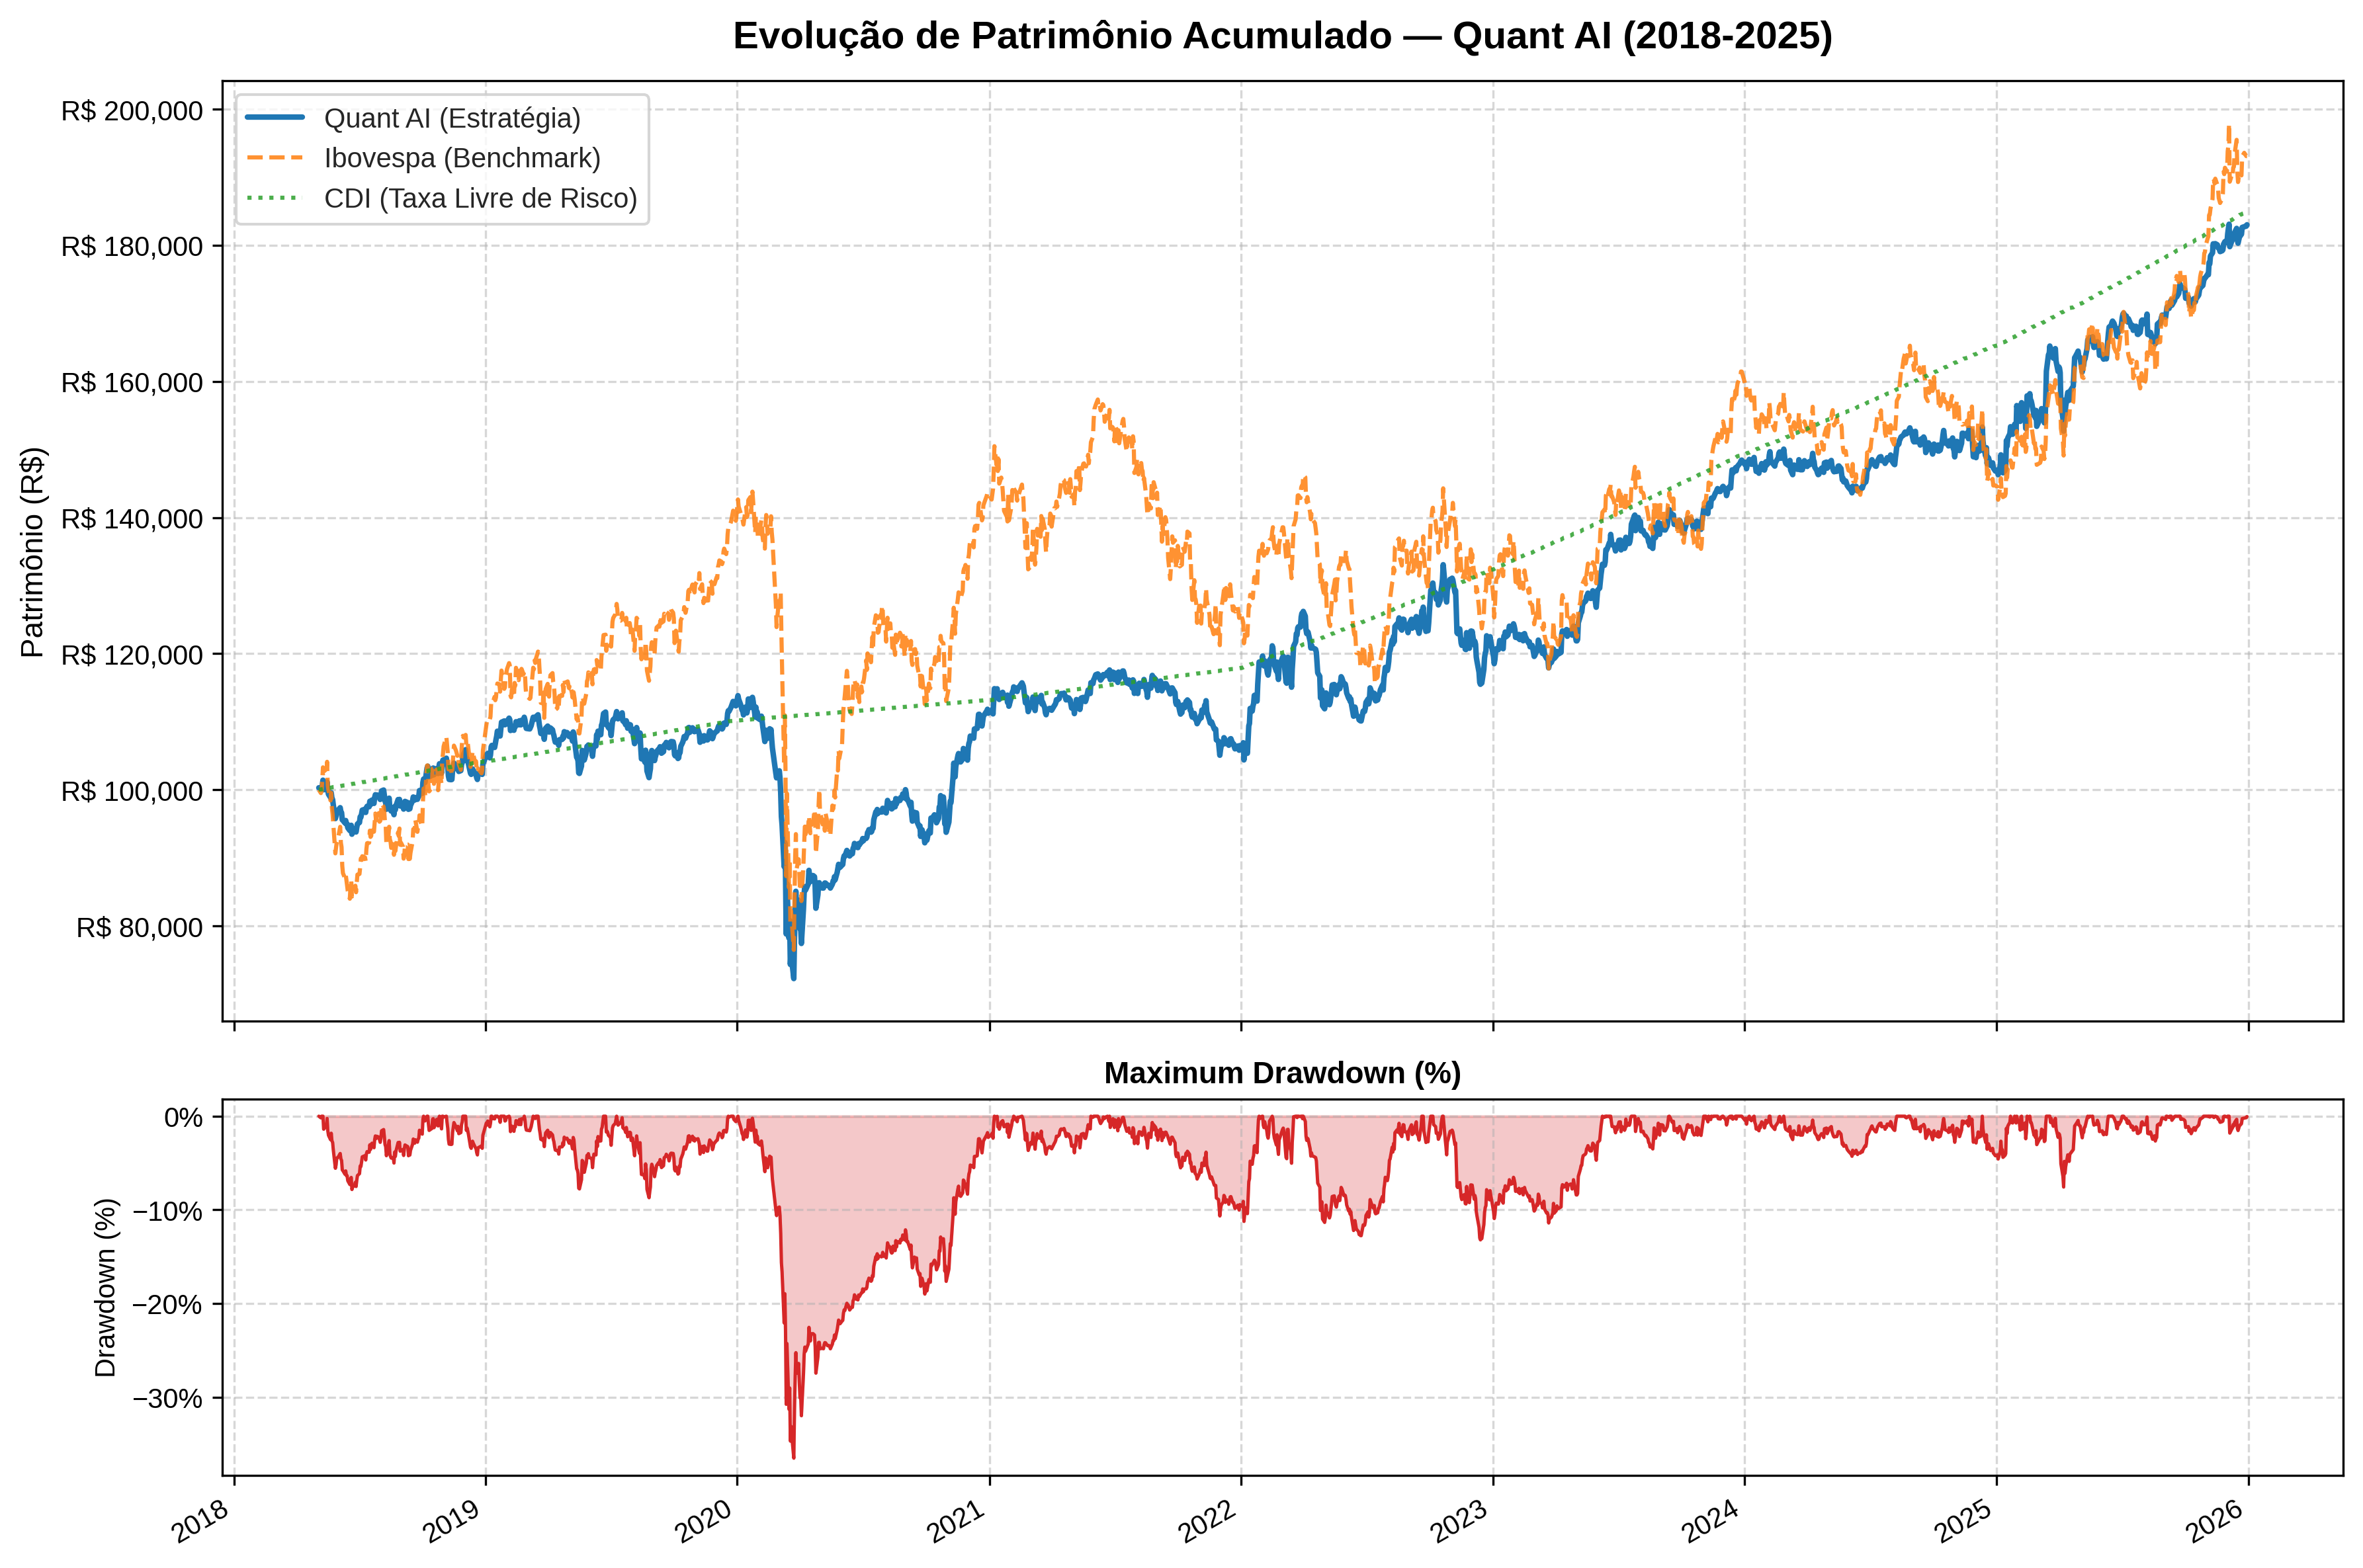


=== 2. EVOLUÇÃO DA ALOCAÇÃO HISTÓRICA DE PESOS ===


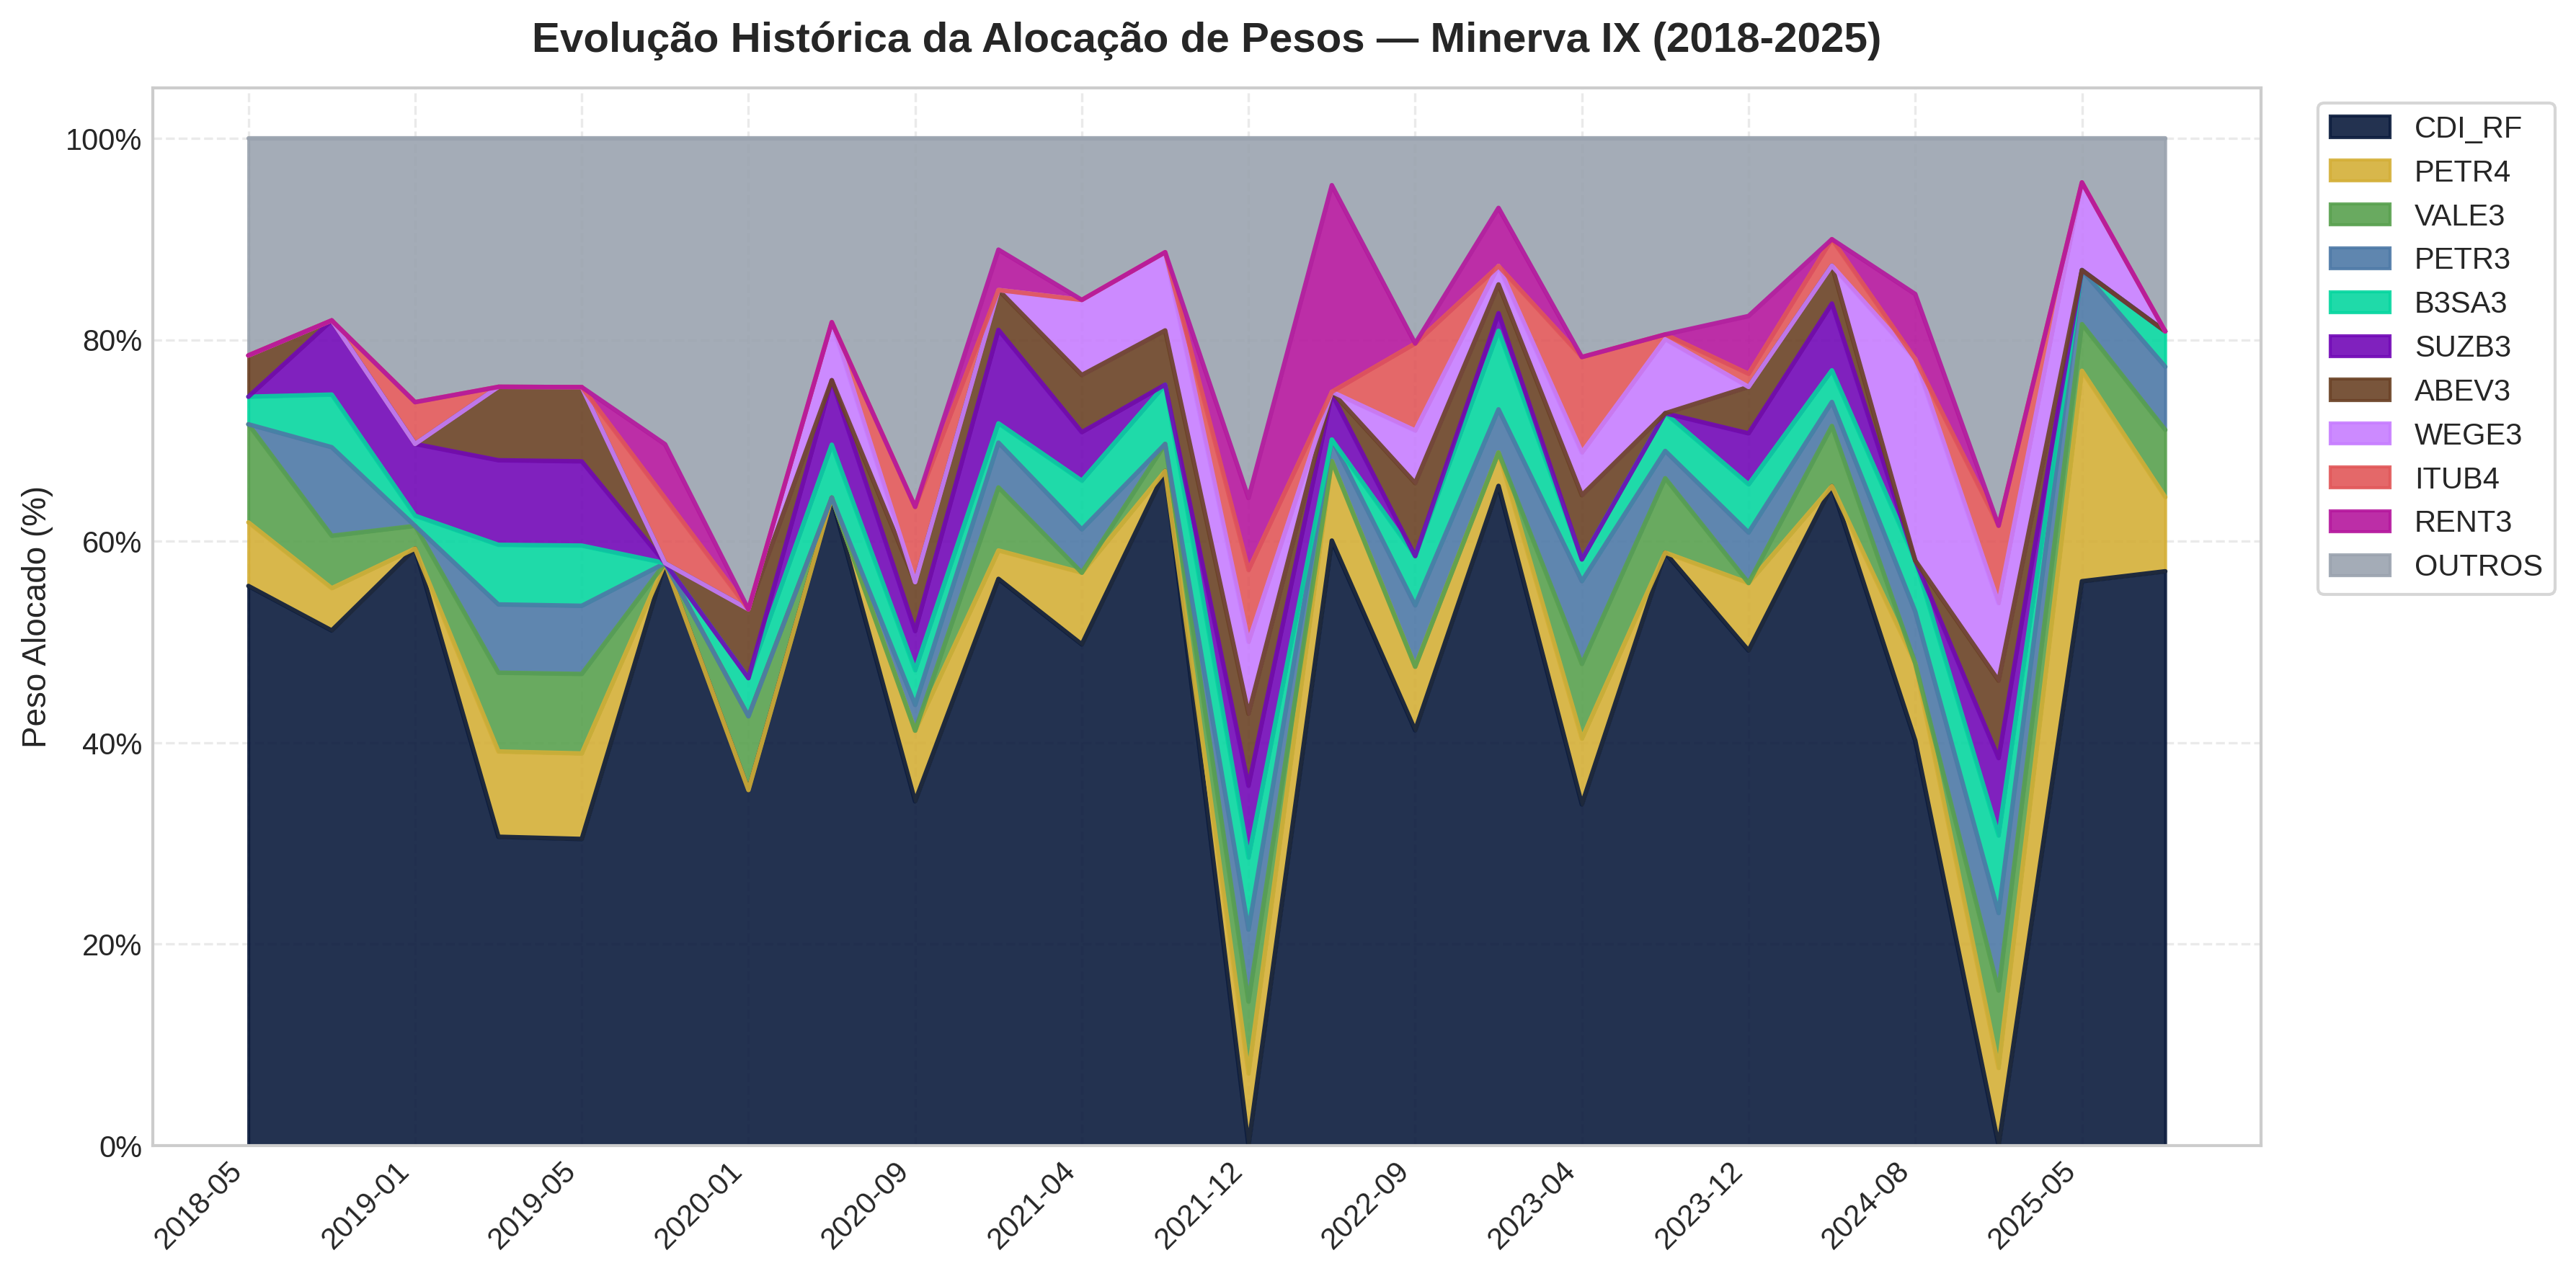

In [6]:
from IPython.display import Image, display
import os

pasta = "relatorios_graficos"
img1 = os.path.join(pasta, "curva_patrimonio_e_drawdown.png")
img2 = os.path.join(pasta, "alocacao_pesos_historica.png")

if os.path.exists(img1):
    print("=== 1. CURVA DE PATRIMÔNIO E DRAWDOWN ===")
    display(Image(img1))

if os.path.exists(img2):
    print("\n=== 2. EVOLUÇÃO DA ALOCAÇÃO HISTÓRICA DE PESOS ===")
    display(Image(img2))

## Painel de Diagnóstico de Sentimento

Estatísticas por ativo -- confirmar dispersão real dos scores antes de confiar no resultado do backtest acima.


In [7]:
import os
import sys
import subprocess
import pandas as pd

# 1. Garante que está no diretório correto dos agentes
if not os.path.exists("processar_noticias_reais.py"):
    for root, dirs, files in os.walk("/content"):
        if "processar_noticias_reais.py" in files:
            os.chdir(root)
            if root not in sys.path:
                sys.path.insert(0, root)
            break

# 2. Se o arquivo ainda não existir, gera ele agora via processar_noticias_reais.py
caminho_csv = "/content/drive/MyDrive/QuantAI/sentimento_agregado_diario.csv"
if not os.path.exists(caminho_csv):
    print("-> Gerando base de sentimento agregada via processar_noticias_reais.py...")
    res = subprocess.run([sys.executable, "processar_noticias_reais.py"], capture_output=True, text=True)
    print(res.stdout)

# 3. Exibe o resumo das notícias e sentimentos processados
if os.path.exists(caminho_csv):
    df_sent = pd.read_csv(caminho_csv)
    print("\n=== TOP 10 SINAIS DE SENTIMENTO MAIS FORTES (AGENTE 3) ===")
    print(df_sent.sort_values("score_meta", ascending=False).head(10)[["data", "ticker", "n_noticias", "s1", "s2", "s3", "score_meta"]].to_string(index=False))

    print("\n=== RESUMO DE NOTÍCIAS E SENTIMENTO POR ATIVO ===")
    resumo = df_sent.groupby("ticker").agg(
        total_noticias=("n_noticias", "sum"),
        score_medio=("score_meta", "mean"),
        maior_alta=("score_meta", "max"),
        maior_queda=("score_meta", "min")
    ).reset_index()
    print(resumo.to_string(index=False))
else:
    print("[ERRO] Não foi possível gerar 'sentimento_agregado_diario.csv'.")


=== TOP 10 SINAIS DE SENTIMENTO MAIS FORTES (AGENTE 3) ===
      data ticker  n_noticias  s1  s2  s3  score_meta
2018-01-22  EQTL3           1 1.0 1.0 1.0         1.0
2018-01-25  RENT3           1 1.0 1.0 1.0         1.0
2018-03-23  EQTL3           1 1.0 1.0 1.0         1.0
2018-02-19  PETR4           1 1.0 1.0 1.0         1.0
2020-05-07  ELET3           1 1.0 1.0 1.0         1.0
2020-04-16  ABEV3           1 1.0 1.0 1.0         1.0
2020-03-11  WEGE3           1 1.0 1.0 1.0         1.0
2025-01-28  RENT3           1 1.0 1.0 1.0         1.0
2025-01-15  RENT3           1 1.0 1.0 1.0         1.0
2025-01-30  ITUB4           1 1.0 1.0 1.0         1.0

=== RESUMO DE NOTÍCIAS E SENTIMENTO POR ATIVO ===
ticker  total_noticias  score_medio  maior_alta  maior_queda
 ABEV3              96     0.203125         1.0    -0.750000
 BBAS3             114     0.248567         1.0    -0.730000
 BBDC4              89     0.242097         1.0    -0.706667
 ELET3             110     0.221030         1.0    